# SIS 

**Student Name:** Aitzhanov Nurlybek
**Student ID:** 23B051010  
**Course:** Deep Learning | Spring 2026  
**Date:** February 11, 2026  
**TASK:** 3

---

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

In [2]:
# Data
RANDOM_STATE = 40

X, y = make_moons(n_samples=1000, noise=0.2, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (800, 2) Test: (200, 2)


In [ ]:
# =========================
# Count parameters in MLP
# =========================
def count_params_mlp(layer_sizes):
    """
    layer_sizes example:
    [2, 8, 1] or [2, 16, 8, 1]

    Formula:
    Params = sum(n_in * n_out + n_out)
    """
    total = 0

    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        weights = n_in * n_out
        biases = n_out
        total += weights + biases

    return total


# =========================
# Evaluate model performance
# =========================
def evaluate_model(name, model, X_train, y_train, X_test, y_test):

    start = time.perf_counter()

    model.fit(X_train, y_train)

    train_time = time.perf_counter() - start

    y_pred = model.predict(X_test)

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Training time (s)": train_time
    }

    return results



In [11]:
#  Define model
perceptron = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", Perceptron(random_state=RANDOM_STATE, max_iter=2000, tol=1e-4))
])


def make_mlp(hidden_layers, max_iter=3000):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=max_iter,
            random_state=RANDOM_STATE,
            early_stopping=True,
            n_iter_no_change=20
        ))
    ])

def plot_decision_boundary(model, X, y, title="Decision boundary", cmap="viridis"):

    import numpy as np
    import matplotlib.pyplot as plt

    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))

    # background colors
    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.35,
        cmap=cmap
    )

    # data points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=cmap,
        s=22,
        edgecolors="black",
        linewidths=0.4
    )

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")

    plt.tight_layout()
    plt.show()

In [5]:
### TABLE 1
results_table1 = []

# Perceptron
results_table1.append(evaluate_model("Perceptron (2-1)", perceptron, X_train, y_train, X_test, y_test))

# Required MLP (2-4-1)
mlp_2_4_1 = make_mlp((4,))
results_table1.append(evaluate_model("MLP (2-4-1)", mlp_2_4_1, X_train, y_train, X_test, y_test))

samples = [
    (8,),        
    (16,),       
    (16, 8),     
    (3,)         
]

for arch in samples:
    name = "MLP (2-" + "-".join(map(str, arch)) + "-1)"
    model = make_mlp(arch)
    results_table1.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

df1 = pd.DataFrame(results_table1)
df1

,Model,Accuracy,Precision,Recall,F1,Training time (s)
0,Perceptron (2-1),0.825,0.933333,0.70,0.800000,0.006323
1,MLP (2-4-1),0.825,0.798165,0.87,0.832536,0.129540
2,MLP (2-8-1),0.490,0.000000,0.00,0.000000,0.026460
3,MLP (2-16-1),0.885,0.932584,0.83,0.878307,0.057158
4,MLP (2-16-8-1),0.500,0.500000,1.00,0.666667,0.033222
5,MLP (2-3-1),0.500,0.500000,1.00,0.666667,0.024101


In [6]:
def params_for_name(model_name):
    
    if not model_name.startswith("MLP"):
        return np.nan
    inside = model_name.split("(")[1].split(")")[0]  
    sizes = list(map(int, inside.split("-")))
    return count_params_mlp(sizes)

df1["Parameters"] = df1["Model"].apply(params_for_name)
df1

,Model,Accuracy,Precision,Recall,F1,Training time (s),Parameters
0,Perceptron (2-1),0.825,0.933333,0.70,0.800000,0.006323,NaN
1,MLP (2-4-1),0.825,0.798165,0.87,0.832536,0.129540,17.0
2,MLP (2-8-1),0.490,0.000000,0.00,0.000000,0.026460,33.0
3,MLP (2-16-1),0.885,0.932584,0.83,0.878307,0.057158,65.0
4,MLP (2-16-8-1),0.500,0.500000,1.00,0.666667,0.033222,193.0
5,MLP (2-3-1),0.500,0.500000,1.00,0.666667,0.024101,13.0


In [7]:
## TABLE 2
widths = [4, 8, 16, 32, 64]
rows = []

for h in widths:
    model = make_mlp((h,))
    res = evaluate_model(f"MLP (2-{h}-1)", model, X_train, y_train, X_test, y_test)
    res["Parameters"] = count_params_mlp([2, h, 1])
    rows.append({
        "Width (hidden neurons)": h,
        "Parameters": res["Parameters"],
        "Accuracy": res["Accuracy"],
        "F1": res["F1"]
    })

df2 = pd.DataFrame(rows)
df2

,Width (hidden neurons),Parameters,Accuracy,F1
0,4,17,0.825,0.832536
1,8,33,0.490,0.000000
2,16,65,0.885,0.878307
3,32,129,0.860,0.864078
4,64,257,0.905,0.909091


In [8]:
## TABLE 3
depths = [1, 2, 3, 4]
rows = []

for d in depths:
    hidden = tuple([8] * d)  
    model = make_mlp(hidden)
    res = evaluate_model(f"MLP (2-{'-'.join(['8']*d)}-1)", model, X_train, y_train, X_test, y_test)
    layer_sizes = [2] + [8]*d + [1]
    rows.append({
        "Depth (hidden layers)": d,
        "Architecture": "2-" + "-".join(["8"]*d) + "-1",
        "Parameters": count_params_mlp(layer_sizes),
        "Accuracy": res["Accuracy"]
    })

df3 = pd.DataFrame(rows)
df3

,Depth (hidden layers),Architecture,Parameters,Accuracy
0,1,2-8-1,33,0.490
1,2,2-8-8-1,105,0.825
2,3,2-8-8-8-1,177,0.835
3,4,2-8-8-8-8-1,249,0.835


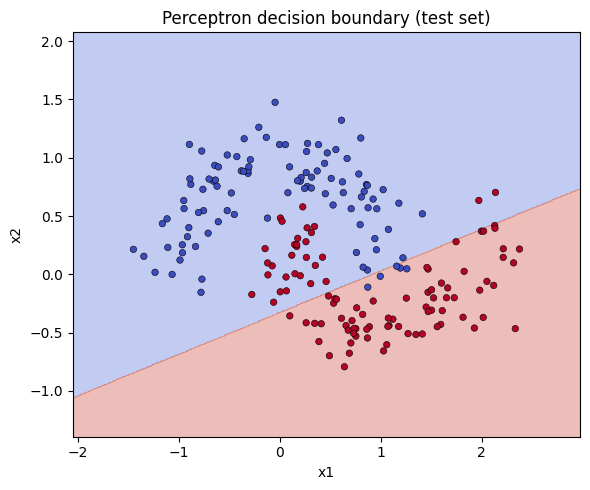

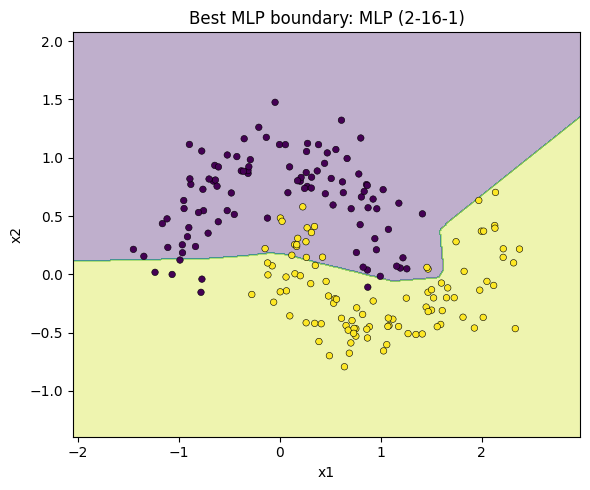

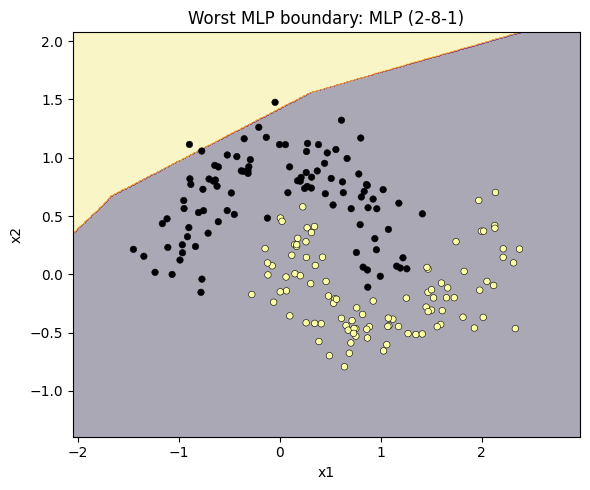

Best model: MLP (2-16-1)
Worst model: MLP (2-8-1)


In [ ]:

# TASK 4


# --- Perceptron ---
perceptron.fit(X_train, y_train)

plot_decision_boundary(
    perceptron,
    X_test,
    y_test,
    title="Perceptron decision boundary (test set)",
    cmap="coolwarm"      # changed color
)


# =========================
# Prepare MLP architecture map
# =========================

mlp_candidates = []

for arch in samples + [(4,), (8,), (16,), (16, 8), (3,)]:
    name = "MLP (2-" + "-".join(map(str, arch)) + "-1)"
    mlp_candidates.append((name, arch))


mlp_arch_map = []

for arch in [(4,)] + samples:
    name = "MLP (2-" + "-".join(map(str, arch)) + "-1)"
    mlp_arch_map.append((name, arch))


# =========================
# Find best and worst MLP from df1
# =========================

mlp_df = df1[df1["Model"].str.startswith("MLP")].copy()

best_name = mlp_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]["Model"]

worst_name = mlp_df.sort_values(
    "Accuracy",
    ascending=True
).iloc[0]["Model"]


# =========================
# Extract architecture from model name
# =========================

def arch_from_model_name(model_name):

    # Example: "MLP (2-16-8-1)"
    inside = model_name.split("(")[1].split(")")[0]

    sizes = list(map(int, inside.split("-")))

    # remove input and output layers
    return tuple(sizes[1:-1])


best_arch = arch_from_model_name(best_name)
worst_arch = arch_from_model_name(worst_name)


# =========================
# Train best and worst models
# =========================

best_model = make_mlp(best_arch)
worst_model = make_mlp(worst_arch)

best_model.fit(X_train, y_train)
worst_model.fit(X_train, y_train)


# =========================
# Plot boundaries with different colors
# =========================

# Best model — green/blue professional look
plot_decision_boundary(
    best_model,
    X_test,
    y_test,
    title=f"Best MLP boundary: {best_name}",
    cmap="viridis"
)


# Worst model — strong contrast look
plot_decision_boundary(
    worst_model,
    X_test,
    y_test,
    title=f"Worst MLP boundary: {worst_name}",
    cmap="inferno"
)


# =========================
# Print results
# =========================

print("Best model:", best_name)
print("Worst model:", worst_name)